Best hyper-parameters: {'svc__C': 5, 'svc__gamma': 0.1, 'svc__kernel': 'rbf', 'svc__tol': 0.001}
Best accuracy score: 63.64%
Test accuracy: 63.75%
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.00      0.00      0.00        11
           5       0.69      0.71      0.70       136
           6       0.60      0.66      0.63       128
           7       0.71      0.55      0.62        40
           8       0.00      0.00      0.00         3

    accuracy                           0.64       320
   macro avg       0.33      0.32      0.33       320
weighted avg       0.62      0.64      0.63       320



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


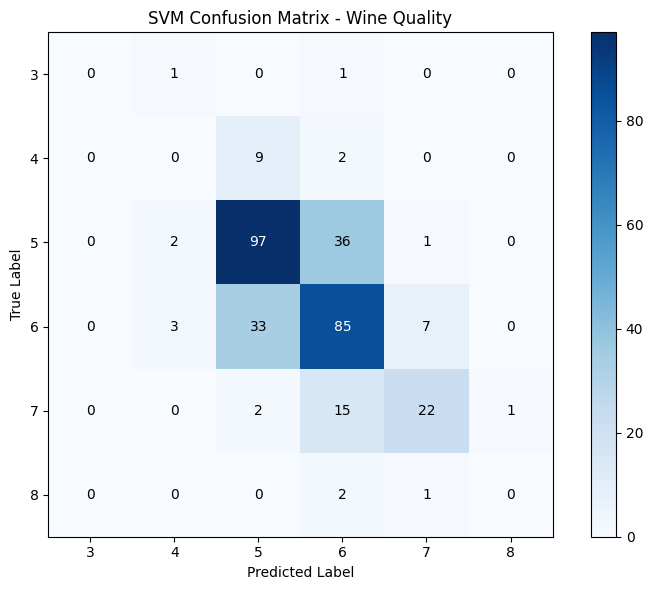

In [5]:
## Final Project -- SVM Model

from sklearn import svm
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import pandas as pd
import re
import numpy as np
import matplotlib.pyplot as plt

#Manually load and split data
with open('winequality-red-1.csv', 'r') as f:
    header_line = f.readline().strip()
raw_column_names = header_line.split(';')
cleaned_column_names = [col.strip().strip('"') for col in raw_column_names]

#Read the CSV data
df = pd.read_csv('winequality-red-1.csv', sep=';', engine='python', skiprows=1, names=cleaned_column_names)
X = df.drop('quality', axis=1)
y = df['quality']

#Split into training/testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

#Pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', svm.SVC())
])


#Parameter grid
param_grid = {
    'svc__C':      [0.01, 0.1, 0.5, 1, 2, 5, 10, 50, 100],
    'svc__kernel': ['linear', 'rbf', 'sigmoid', 'poly'],
    'svc__gamma':  ['scale', 'auto', 0.001, 0.01, 0.1],
    'svc__tol':    [1e-3, 1e-2]
}

#Grid search
grid_search = GridSearchCV(pipeline, param_grid, scoring='accuracy', cv=5, n_jobs=-1)
gs_results = grid_search.fit(X_train, y_train)

print("Best hyper-parameters:", gs_results.best_params_)
print("Best accuracy score: {:.2f}%".format(gs_results.best_score_ * 100))

#Results
test_accuracy = gs_results.score(X_test, y_test)
print("Test accuracy: {:.2f}%".format(test_accuracy * 100))
y_pred = gs_results.predict(X_test)
print(classification_report(y_test, y_pred))

#Plots

#Confusion Matric
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.colorbar(im)
classes = sorted(y.unique())
ax.set(xticks=np.arange(len(classes)),
       yticks=np.arange(len(classes)),
       xticklabels=classes,
       yticklabels=classes,
       xlabel='Predicted Label',
       ylabel='True Label',
       title='SVM Confusion Matrix - Wine Quality')
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha='center', va='center',
                color='white' if cm[i, j] > cm.max()/2 else 'black')
plt.tight_layout()
plt.show()